<a href="https://colab.research.google.com/github/Jaang12/aa/blob/main/Temporal_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow==2.12.0

INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 660.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 107.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 25.3 MB/s eta 0:00:00
 

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install opencv-python

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, Input, PReLU, BatchNormalization
from tensorflow.keras import initializers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import os
import cv2

In [ ]:
for i in range(0, 1024 - 128 + 1, 128):
  print(i)

0
128
256
384
512
640
768
896


In [ ]:
# training, validation data 생성
all_blocks = []

file_paths = [
    '/content/drive/MyDrive/dataset/temporal/isotropic1024coarse/velocity_data_t_10_xy_1024_z_1.npy',
    '/content/drive/MyDrive/dataset/temporal/isotropic1024coarse/velocity_data_t_10_xy_1024_z_128.npy',
    '/content/drive/MyDrive/dataset/temporal/isotropic1024coarse/velocity_data_t_10_xy_1024_z_256.npy',
    '/content/drive/MyDrive/dataset/temporal/isotropic1024coarse/velocity_data_t_10_xy_1024_z_384.npy',
    '/content/drive/MyDrive/dataset/temporal/isotropic1024coarse/velocity_data_t_10_xy_1024_z_512.npy'
]

for path in file_paths:
    data = np.load(path)  # shape: (10, 1, 1024, 1024, 3)
    blocks = []

    for i in range(0, 1024, 128):
        for j in range(0, 1024, 128):
            block = data[:, :, i:i+128, j:j+128, :]  # shape: (10, 1, 128, 128, 3)
            blocks.append(block)

    blocks = np.stack(blocks).squeeze(axis=2)  # shape: (64, 10, 128, 128, 3)
    all_blocks.append(blocks)

# 최종 학습용 데이터: (320, 10, 128, 128, 3)
full_dataset = np.concatenate(all_blocks, axis=0)
print("총 학습 데이터 shape:", full_dataset.shape)

총 학습 데이터 shape: (320, 10, 128, 128, 3)


In [ ]:
# training data 저장
os.makedirs('/content/drive/MyDrive/dataset/temporal/isotropic1024coarse', exist_ok=True)
np.save('/content/drive/MyDrive/dataset/temporal/isotropic1024coarse/full_training_data_320.npy', full_dataset)

In [ ]:
# training data 불러오기
full_dataset = np.load('/content/drive/MyDrive/dataset/temporal/isotropic1024coarse/full_training_data_320.npy')

In [ ]:
# test 데이터 생성
data = np.load('/content/drive/MyDrive/dataset/temporal/isotropic1024coarse/velocity_data_t_10_xy_1024_z_768.npy')
print("원본 shape:", data.shape)  # (10, 1, 1024, 1024, 3)

# 결과 저장 리스트
blocks = []

# x, y 방향으로 자르기 (128씩 → 8x8 = 64개)
for i in range(0, 1024, 128):
    for j in range(0, 1024, 128):
        # x: axis=2, y: axis=3
        block = data[:, :, i:i+128, j:j+128, :]  # shape: (10, 1, 128, 128, 3)
        blocks.append(block)

# 리스트 → numpy 배열
blocks = np.stack(blocks).squeeze(axis=2)  # shape: (64, 10, 128, 128, 3)
test_data = blocks
print("테스트 데이터 shape:", test_data.shape)

원본 shape: (10, 1, 1024, 1024, 3)
테스트 데이터 shape: (64, 10, 128, 128, 3)


In [ ]:
# test data 저장
os.makedirs('/content/drive/MyDrive/dataset/temporal/isotropic1024coarse', exist_ok=True)
np.save('/content/drive/MyDrive/dataset/temporal/isotropic1024coarse/full_test_data_64.npy', test_data)

In [ ]:
# test data 불러오기
full_dataset = np.load('/content/drive/MyDrive/dataset/temporal/isotropic1024coarse/full_test_data_64.npy')

In [ ]:
# 전체 데이터의 최소/최대값
data_min = full_dataset.min()
data_max = full_dataset.max()

# train, validation, test 데이터 정규화 (0 ~ 1)
normalized_dataset = (full_dataset - data_min) / (data_max - data_min)
test_data = (test_data - data_min) / (data_max - data_min)

In [ ]:
# 데이터 분할
train_data, val_data = train_test_split(
    normalized_dataset,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

train_data = train_data.astype('float32')
val_data = val_data.astype('float32')
test_data = test_data.astype('float32')

print("Train shape:", train_data.shape)
print("Validation shape:", val_data.shape)
print("Test shape:", test_data.shape)

# 데이터 전처리
# 평균과 표준편차를 이용한 정규화
# mean_val = np.mean(lr_train)
# std_val = np.std(lr_train)

# lr_train = (lr_train - mean_val) / std_val
# lr_val = (lr_val - mean_val) / std_val
# lr_test = (lr_test - mean_val) / std_val

Train shape: (256, 10, 128, 128, 3)
Validation shape: (64, 10, 128, 128, 3)
Test shape: (64, 10, 128, 128, 3)


In [ ]:
# CNN, t => t+1 예측모델
# (:, t, :, :, :) => (:, t+1, :, :, :)

from tensorflow.keras import Model, layers, initializers

class TemporalCNN(Model):
    def __init__(self):
        super(TemporalCNN, self).__init__()
        self.initializer = initializers.HeNormal(seed=33)

        # Conv Block 1
        self.conv1 = layers.Conv2D(64, kernel_size=5, padding='same', kernel_initializer=self.initializer)
        self.prelu1 = layers.PReLU()
        self.norm1 = layers.BatchNormalization()

        # Conv Block 2
        self.conv2 = layers.Conv2D(128, kernel_size=3, padding='same', kernel_initializer=self.initializer)
        self.prelu2 = layers.PReLU()
        self.norm2 = layers.BatchNormalization()

        # Feature Refinement
        self.conv3 = layers.Conv2D(128, kernel_size=3, padding='same', kernel_initializer=self.initializer)
        self.conv4 = layers.Conv2D(64, kernel_size=3, padding='same', kernel_initializer=self.initializer)

        # Output layer (no activation)
        self.conv5 = layers.Conv2D(3, kernel_size=3, padding='same', kernel_initializer=self.initializer)

    def call(self, inputs, training=False):
        x = self.conv1(inputs)
        x = self.prelu1(x)
        x = self.norm1(x, training=training)

        x = self.conv2(x)
        x = self.prelu2(x)
        x = self.norm2(x, training=training)

        x = self.conv3(x)
        x = self.conv4(x)

        return self.conv5(x)

def continuity_loss(y_pred):
    """Finite difference 기반 divergence loss (∂u/∂x + ∂v/∂y)"""
    u = y_pred[..., 0]  # shape: (batch, H, W)
    v = y_pred[..., 1]  # shape: (batch, H, W)

    # finite difference (단순한 backward 차분)
    du_dx = u[:, :, 1:] - u[:, :, :-1]  # shape: (batch, H, W-1)
    dv_dy = v[:, 1:, :] - v[:, :-1, :]  # shape: (batch, H-1, W)

    # 크기 맞추기 위해 패딩
    du_dx = tf.pad(du_dx, [[0, 0], [0, 0], [0, 1]])  # W 방향 끝에 padding
    dv_dy = tf.pad(dv_dy, [[0, 0], [0, 1], [0, 0]])  # H 방향 끝에 padding

    div = du_dx + dv_dy
    return tf.reduce_mean(tf.square(div))

def custom_loss(y_true, y_pred, lambda_cont=0.5):
    loss_mse = tf.reduce_mean(tf.square(y_true - y_pred))
    loss_cont = continuity_loss(y_pred)
    return loss_mse + lambda_cont * loss_cont

def PSNR(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred), axis=(1, 2, 3))
    mse = tf.maximum(mse, 1e-10)  # 안정성 추가
    psnr = 20 * tf.math.log(1.0 / tf.math.sqrt(mse)) / tf.math.log(10.0)
    return psnr

TemporalCNN_model = TemporalCNN()
TemporalCNN_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=custom_loss,
    metrics=[PSNR]
)

TemporalCNN_model.build(input_shape=(None, 128, 128, 3))
TemporalCNN_model.summary()

Model: "temporal_cnn_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_35 (Conv2D)          multiple                  4864      
                                                                 
 p_re_lu_14 (PReLU)          multiple                  1048576   
                                                                 
 batch_normalization_14 (Bat  multiple                 256       
 chNormalization)                                                
                                                                 
 conv2d_36 (Conv2D)          multiple                  73856     
                                                                 
 p_re_lu_15 (PReLU)          multiple                  2097152   
                                                                 
 batch_normalization_15 (Bat  multiple                 512       
 chNormalization)                                   

In [ ]:
# 가상의 input을 넣어 output의 크기가 잘 나오는지 확인
sample_input = tf.random.normal((1, 128, 128, 3))  # 배치 크기 1짜리 샘플 생성
sample_output = TemporalCNN_model(sample_input)  # 모델에 입력 넣기
print(sample_output.shape)  # 출력 크기 확인

(1, 128, 128, 3)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import pickle

# 폴더 생성
os.makedirs("/content/drive/MyDrive/history_logs", exist_ok=True)
os.makedirs("/content/drive/MyDrive/model", exist_ok=True)

num_timesteps = 10
input_shape = (128, 128, 3)
EPOCHS = 500
batch_size = 32

for t in range(num_timesteps - 1):
    print(f'\nTraining model_{t}{t+1} for t={t} → t={t+1}...')

    x_train = train_data[:, t]
    y_train = train_data[:, t + 1]
    x_val   = val_data[:, t]
    y_val   = val_data[:, t + 1]

    # 모델 초기화
    model = TemporalCNN()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=custom_loss,
        metrics=[PSNR]
    )
    model.build(input_shape=(None, *input_shape))

    # 저장 디렉토리 지정 (파일이 아니라 폴더)
    checkpoint_path = f"/content/drive/MyDrive/weight/best_model_{t}{t+1}"

    # ModelCheckpoint 콜백 설정
    model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False  # 만약 val_loss가 더 낮아지는 경우에 모델 전체 저장
    )

    # early_stopping 콜백 설정
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )

    # 학습 코드
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=batch_size,
        verbose=1,
        callbacks=[early_stopping, model_checkpoint]
    )

    # best 모델을 다시 불러와서 저장 (이건 이미 모델 전체 저장되었기 때문에 선택사항)
    best_model = tf.keras.models.load_model(checkpoint_path, custom_objects={'custom_loss': custom_loss, 'PSNR': PSNR})
    best_model.save(f'model_{t}{t+1}')
    print(f'Saved best full model to model_{t}{t+1}.h5')

    # 히스토리 저장
    with open(f'history_logs/history_{t}{t+1}.pkl', 'wb') as f:
        pickle.dump(history.history, f)
    print(f'Saved training history_{t}{t+1}.pkl')


Training model_01 for t=0 → t=1...
Epoch 1/500
8/8 [==============================] - ETA: 0s - loss: 11.4001 - PSNR: -7.0272

8/8 [==============================] - 33s 4s/step - loss: 11.4001 - PSNR: -7.0272 - val_loss: 0.2237 - val_PSNR: 6.8141
Epoch 2/500
8/8 [==============================] - 29s 4s/step - loss: 1.6966 - PSNR: -0.8921 - val_loss: 0.3723 - val_PSNR: 4.5289
Epoch 3/500
8/8 [==============================] - 29s 4s/step - loss: 0.7053 - PSNR: 2.8388 - val_loss: 0.5346 - val_PSNR: 2.9766
Epoch 4/500
8/8 [==============================] - 30s 4s/step - loss: 0.3422 - PSNR: 5.8458 - val_loss: 0.3898 - val_PSNR: 4.3047
Epoch 5/500
8/8 [==============================] - ETA: 0s - loss: 0.1978 - PSNR: 8.1552

8/8 [==============================] - 31s 4s/step - loss: 0.1978 - PSNR: 8.1552 - val_loss: 0.1895 - val_PSNR: 7.6970
Epoch 6/500
8/8 [==============================] - ETA: 0s - loss: 0.1360 - PSNR: 9.7718

8/8 [==============================] - 31s 4s/step - loss: 0.1360 - PSNR: 9.7718 - val_loss: 0.1313 - val_PSNR: 9.3306
Epoch 7/500
8/8 [==============================] - 30s 4s/step - loss: 0.0943 - PSNR: 11.4763 - val_loss: 0.1369 - val_PSNR: 9.1353
Epoch 8/500
8/8 [==============================] - ETA: 0s - loss: 0.0749 - PSNR: 12.4865

8/8 [==============================] - 31s 4s/step - loss: 0.0749 - PSNR: 12.4865 - val_loss: 0.0883 - val_PSNR: 11.0732
Epoch 9/500
8/8 [==============================] - ETA: 0s - loss: 0.0648 - PSNR: 13.1868

...

8/8 [==============================] - 31s 4s/step - loss: 0.0371 - PSNR: 15.5376 - val_loss: 0.0335 - val_PSNR: 15.5578
Epoch 21/500
8/8 [==============================] - 30s 4s/step - loss: 0.0354 - PSNR: 15.6839 - val_loss: 0.0343 - val_PSNR: 15.4363
Epoch 22/500
8/8 [==============================] - ETA: 0s - loss: 0.0348 - PSNR: 15.7550

8/8 [==============================] - 31s 4s/step - loss: 0.0348 - PSNR: 15.7550 - val_loss: 0.0321 - val_PSNR: 15.7008
Epoch 23/500
8/8 [==============================] - 30s 4s/step - loss: 0.0319 - PSNR: 16.1635 - val_loss: 0.0331 - val_PSNR: 15.5873
Epoch 24/500
8/8 [==============================] - ETA: 0s - loss: 0.0335 - PSNR: 15.9886

8/8 [==============================] - 31s 4s/step - loss: 0.0335 - PSNR: 15.9886 - val_loss: 0.0320 - val_PSNR: 15.7148
Epoch 25/500
8/8 [==============================] - 30s 4s/step - loss: 0.0311 - PSNR: 16.3078 - val_loss: 0.0327 - val_PSNR: 15.5650
Epoch 26/500
8/8 [==============================] - ETA: 0s - loss: 0.0301 - PSNR: 16.4723

8/8 [==============================] - 32s 4s/step - loss: 0.0301 - PSNR: 16.4723 - val_loss: 0.0309 - val_PSNR: 15.7901
Epoch 27/500
8/8 [==============================] - 30s 4s/step - loss: 0.0279 - PSNR: 16.7192 - val_loss: 0.0318 - val_PSNR: 15.6787
Epoch 28/500
8/8 [==============================] - 30s 4s/step - loss: 0.0277 - PSNR: 16.7468 - val_loss: 0.0325 - val_PSNR: 15.6273
Epoch 29/500
8/8 [==============================] - 30s 4s/step - loss: 0.0264 - PSNR: 16.9189 - val_loss: 0.0328 - val_PSNR: 15.5769
Epoch 30/500
8/8 [==============================] - 30s 4s/step - loss: 0.0270 - PSNR: 16.8932 - val_loss: 0.0314 - val_PSNR: 15.7157
Epoch 31/500
8/8 [==============================] - 30s 4s/step - loss: 0.0269 - PSNR: 17.0198 - val_loss: 0.0333 - val_PSNR: 15.4713
Epoch 32/500
8/8 [==============================] - 30s 4s/step - loss: 0.0250 - PSNR: 17.2257 - val_loss: 0.0323 - val_PSNR: 15.6615
Epoch 33/500
8/8 [==============================] - 30s 4s/step - loss: 0.0

NotImplementedError: Saving the model to HDF5 format requires the model to be a Functional model or a Sequential model. It does not work for subclassed models, because such models are defined via the body of a Python method, which isn't safely serializable. Consider saving to the Tensorflow SavedModel format (by setting save_format="tf") or using `save_weights`.

In [ ]:
# 전체 히스토리 시각화
import pickle

history_folder = "history_logs"
num_models = 9  # t=0~9 → 0→1, ..., 8→9

# 전체 히스토리를 담을 딕셔너리
all_histories = {}

for t in range(num_models):
    filename = f"history_{t}{t+1}.pkl"
    path = os.path.join(history_folder, filename)

    if os.path.exists(path):
        with open(path, 'rb') as f:
            hist = pickle.load(f)
            all_histories[f"{t}{t+1}"] = hist
    else:
        print(f"{filename} not found.")

# 1. 전체 loss 그래프 비교
plt.figure(figsize=(10, 6))
for key, hist in all_histories.items():
    plt.plot(hist['val_loss'], label=f'Val Loss {key}')
plt.title('Validation Loss Across All Models')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 2. 전체 PSNR 그래프 비교
plt.figure(figsize=(10, 6))
for key, hist in all_histories.items():
    plt.plot(hist['val_PSNR'], label=f'Val PSNR {key}')
plt.title('Validation PSNR Across All Models')
plt.xlabel('Epoch')
plt.ylabel('PSNR')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# val_data에서 하나 선택해 간단히 확인
# 예측 시작할 초기 입력 프레임 (예: val_data[0, 0])
initial_input = val_data[0, 0]  # shape: (128, 128, 3)
current_input = np.expand_dims(initial_input, axis=0)  # shape: (1, 128, 128, 3)

predictions = [current_input[0]]  # 첫 프레임 저장

# 순차적으로 모델 불러와서 예측
for t in range(9):  # 0→1, ..., 8→9
    model_path = f'/content/drive/MyDrive/weight/best_model_{t}{t+1}'
    model = tf.keras.models.load_model(model_path, custom_objects={'custom_loss': custom_loss, 'PSNR': PSNR})

    next_output = model.predict(current_input)
    predictions.append(next_output[0])  # 결과 프레임 저장
    current_input = next_output  # 다음 입력으로 사용

predictions = np.array(predictions)  # shape: (10, 128, 128, 3)

In [ ]:
# 예측 프레임과 True 프레임의 GIF를 비교, 저장
def save_comparison_gif(predictions, ground_truths, filename='compare.gif', cmap='inferno'):
    import imageio

    # 저장 경로 설정
    save_dir = '/content/drive/MyDrive/dataset/temporal/isotropic1024coarse/gifs'
    os.makedirs(save_dir, exist_ok=True)
    full_path = os.path.join(save_dir, filename)

    # 임시 프레임 저장 디렉토리
    temp_dir = 'temp_compare_frames'
    os.makedirs(temp_dir, exist_ok=True)
    filepaths = []

    for t, (pred, gt) in enumerate(zip(predictions, ground_truths)):
        pred_img = pred[..., 0]  # u 성분
        gt_img = gt[..., 0]

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(gt_img, cmap=cmap)
        axes[0].set_title(f'GT t={t}')
        axes[0].axis('off')

        axes[1].imshow(pred_img, cmap=cmap)
        axes[1].set_title(f'Pred t={t}')
        axes[1].axis('off')

        filepath = os.path.join(temp_dir, f'compare_{t}.png')
        plt.savefig(filepath, bbox_inches='tight')
        plt.close()
        filepaths.append(filepath)

    # GIF 저장
    with imageio.get_writer(full_path, mode='I', duration=0.5) as writer:
        for path in filepaths:
            image = imageio.imread(path)
            writer.append_data(image)

    # 임시 이미지 정리
    for path in filepaths:
        os.remove(path)
    os.rmdir(temp_dir)

    print(f"Split comparison GIF saved to: {full_path}")

# Ground Truth: (10, 128, 128, 3)
ground_truths = val_data[0]  # 첫 번째 블록의 전체 시퀀스

save_comparison_gif(predictions, ground_truths, filename='compare.gif')

In [ ]:
# 속도장의 에너지 스펙트럼 비교 함수 (pred vs ground truth)
from numpy.fft import fft2, fftshift
def compute_energy_spectrum_2d(vector_field):
    """
    vector_field: shape (H, W, 3), 3 = (u, v, w)
    return: 1D energy spectrum E(k)
    """
    H, W, _ = vector_field.shape

    # FFT 각 성분
    u_hat = fft2(vector_field[..., 0])
    v_hat = fft2(vector_field[..., 1])
    w_hat = fft2(vector_field[..., 2])

    # Power spectral density
    E_u = np.abs(u_hat) ** 2
    E_v = np.abs(v_hat) ** 2
    E_w = np.abs(w_hat) ** 2

    E_total = E_u + E_v + E_w
    E_total = fftshift(E_total)  # 중심 이동

    # 파수 벡터
    kx = np.fft.fftfreq(W) * W
    ky = np.fft.fftfreq(H) * H
    kx, ky = np.meshgrid(kx, ky)
    k_mag = np.sqrt(kx**2 + ky**2)
    k_mag = fftshift(k_mag)

    # 이산 bin에 따라 평균
    k_max = int(np.max(k_mag))
    E_k = np.zeros(k_max)
    counts = np.zeros(k_max)

    for i in range(H):
        for j in range(W):
            k = int(k_mag[i, j])
            if k < k_max:
                E_k[k] += E_total[i, j]
                counts[k] += 1

    # Normalize by number of modes per bin
    E_k = E_k / (counts + 1e-10)

    return E_k

In [ ]:
# 예시: 비교 대상 프레임 (예: t = 9)
t_target = 9
pred_frame = predictions[t_target]      # shape: (128, 128, 3)
gt_frame = val_data[0, t_target]        # shape: (128, 128, 3)

# 계산
Ek_pred = compute_energy_spectrum_2d(pred_frame)
Ek_gt = compute_energy_spectrum_2d(gt_frame)

# 시각화
plt.figure(figsize=(6, 4))
plt.plot(Ek_gt, label='Ground Truth', lw=2)
plt.plot(Ek_pred, label='Prediction', lw=2, linestyle='--')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Wavenumber k')
plt.ylabel('E(k)')
plt.title(f'Energy Spectrum at t={t_target}')
plt.legend()
plt.grid(True, which='both', linestyle=':')
plt.show()

In [ ]:
# 전체 프레임의 평균 속도장 에너지 스펙트럼을 구하는 함수
def compute_mean_energy_spectrum(pred_seq, gt_seq):
    """
    pred_seq, gt_seq: shape (T, H, W, 3)
    return: (E_k_pred_mean, E_k_gt_mean)
    """
    T = pred_seq.shape[0]
    spectra_pred = []
    spectra_gt = []

    for t in range(T):
        Ek_pred = compute_energy_spectrum_2d(pred_seq[t])
        Ek_gt = compute_energy_spectrum_2d(gt_seq[t])

        spectra_pred.append(Ek_pred)
        spectra_gt.append(Ek_gt)

    # padding을 고려해 동일 길이로 잘라내기
    min_len = min([len(s) for s in spectra_pred + spectra_gt])
    spectra_pred = np.array([s[:min_len] for s in spectra_pred])
    spectra_gt = np.array([s[:min_len] for s in spectra_gt])

    return spectra_pred.mean(axis=0), spectra_gt.mean(axis=0)

In [ ]:
# 사용 예시
gt_seq = val_data[0]         # shape: (10, 128, 128, 3)
pred_seq = predictions       # shape: (10, 128, 128, 3)

Ek_pred_mean, Ek_gt_mean = compute_mean_energy_spectrum(pred_seq, gt_seq)

plt.figure(figsize=(6, 4))
plt.plot(Ek_gt_mean, label='GT Mean Spectrum', lw=2)
plt.plot(Ek_pred_mean, label='Pred Mean Spectrum', lw=2, linestyle='--')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Wavenumber k')
plt.ylabel('E(k)')
plt.title('Mean Energy Spectrum over All Timesteps')
plt.legend()
plt.grid(True, which='both', linestyle=':')
plt.show()


In [ ]:
# 2D vorticity 계산 함
def compute_vorticity_2d(velocity_field):
    """
    velocity_field: (H, W, 3) → (u, v, w)
    returns: vorticity ω_z (H, W)
    """
    u = velocity_field[..., 0]
    v = velocity_field[..., 1]

    du_dy = np.gradient(u, axis=0)
    dv_dx = np.gradient(v, axis=1)

    vorticity = dv_dx - du_dy
    return vorticity

# pdf 계산 함수
def compute_pdf(data, bins=100, range=None):
    hist, bin_edges = np.histogram(data.flatten(), bins=bins, density=True, range=range)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    return bin_centers, hist


In [ ]:
# vorticity pdf 비(pred vs ground truth)
# 예시: 마지막 시점 t=9
t_target = 9
vorticity_pred = compute_vorticity_2d(predictions[t_target])
vorticity_gt = compute_vorticity_2d(val_data[0, t_target])

# PDF 계산
bins = 100
v_min = min(vorticity_gt.min(), vorticity_pred.min())
v_max = max(vorticity_gt.max(), vorticity_pred.max())
v_range = (v_min, v_max)

pdf_x_gt, pdf_y_gt = compute_pdf(vorticity_gt, bins=bins, range=v_range)
pdf_x_pred, pdf_y_pred = compute_pdf(vorticity_pred, bins=bins, range=v_range)

# 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(pdf_x_gt, pdf_y_gt, label='GT', lw=2)
plt.plot(pdf_x_pred, pdf_y_pred, label='Prediction', lw=2, linestyle='--')
plt.xlabel('Vorticity ωₓ')
plt.ylabel('Probability Density')
plt.title(f'Vorticity PDF at t={t_target}')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 전체 시간 평균 속도장의 vorticity pdf 비교
# 전체 시간 vorticity pdf 계산 함
def compute_mean_vorticity_pdf(pred_seq, gt_seq, bins=100):
    """
    pred_seq, gt_seq: shape (T, H, W, 3)
    returns: pdf_x (bin center), mean_pdf_pred, mean_pdf_gt
    """
    T = pred_seq.shape[0]

    # 먼저 전체 데이터의 vorticity 값 범위 구하기
    all_vorticities = []
    for t in range(T):
        v_pred = compute_vorticity_2d(pred_seq[t])
        v_gt = compute_vorticity_2d(gt_seq[t])
        all_vorticities.extend([v_pred.flatten(), v_gt.flatten()])

    v_min = min(map(np.min, all_vorticities))
    v_max = max(map(np.max, all_vorticities))
    v_range = (v_min, v_max)

    # 각 프레임의 PDF 계산
    pdfs_pred = []
    pdfs_gt = []

    for t in range(T):
        v_pred = compute_vorticity_2d(pred_seq[t])
        v_gt = compute_vorticity_2d(gt_seq[t])

        x, pdf_pred = compute_pdf(v_pred, bins=bins, range=v_range)
        _, pdf_gt = compute_pdf(v_gt, bins=bins, range=v_range)

        pdfs_pred.append(pdf_pred)
        pdfs_gt.append(pdf_gt)

    # 평균
    mean_pdf_pred = np.mean(pdfs_pred, axis=0)
    mean_pdf_gt = np.mean(pdfs_gt, axis=0)

    return x, mean_pdf_pred, mean_pdf_gt

In [ ]:
# 사용 예시: 전체 시간 평
gt_seq = val_data[0]       # (10, 128, 128, 3)
pred_seq = predictions     # (10, 128, 128, 3)

x_bins, mean_pdf_pred, mean_pdf_gt = compute_mean_vorticity_pdf(pred_seq, gt_seq, bins=100)

# 시각화
plt.figure(figsize=(6, 4))
plt.plot(x_bins, mean_pdf_gt, label='GT Mean PDF', lw=2)
plt.plot(x_bins, mean_pdf_pred, label='Pred Mean PDF', lw=2, linestyle='--')
plt.xlabel('Vorticity ωₓ')
plt.ylabel('Mean Probability Density')
plt.title('Mean Vorticity PDF over Time')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
================================================================================

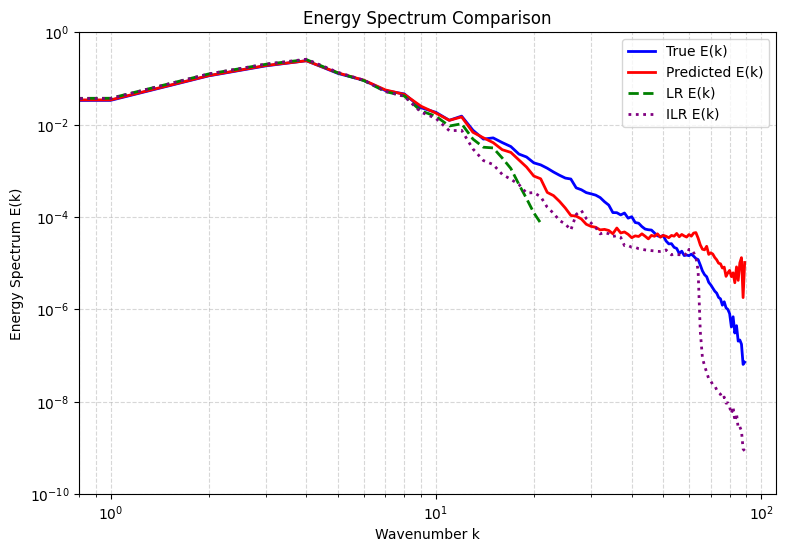

In [ ]:
## 원본과 복원된 에너지 스펙트럼 비교, k_bin을 선형적으로 분할 ## 사용 X
def compute_energy_spectrum(u, v, w):
    """
    속도장(u, v, w)에 대한 에너지 스펙트럼을 계산하는 함수.

    Parameters:
    u (numpy.ndarray): x 방향 속도 성분
    v (numpy.ndarray): y 방향 속도 성분
    w (numpy.ndarray): z 방향 속도 성분

    Returns:
    k (numpy.ndarray): 파수 값
    E_k (numpy.ndarray): 에너지 스펙트럼
    """
    # 속도장 크기
    nx, ny = u.shape

    # 푸리에 변환 적용 (각 속도 성분에 대해)
    u_hat = np.fft.fft2(u) / (nx * ny)
    v_hat = np.fft.fft2(v) / (nx * ny)
    w_hat = np.fft.fft2(w) / (nx * ny)

    # 푸리에 변환 결과를 이동시켜서 중심으로
    u_hat_shifted = np.fft.fftshift(u_hat)
    v_hat_shifted = np.fft.fftshift(v_hat)
    w_hat_shifted = np.fft.fftshift(w_hat)

    # 주파수 벡터 계산 (파수 k_x, k_y)
    dx = 2 * np.pi / nx  # x 방향 공간 간격
    dy = 2 * np.pi / ny  # y 방향 공간 간격

    k_x = np.fft.fftfreq(nx, d=dx) * 2 * np.pi
    k_y = np.fft.fftfreq(ny, d=dy) * 2 * np.pi

    k_x = np.fft.fftshift(k_x)
    k_y = np.fft.fftshift(k_y)

    # k_x, k_y에 대해 그리드 생성
    k_x, k_y = np.meshgrid(k_x, k_y, indexing='ij')
    k = np.sqrt(k_x**2 + k_y**2)  # 전체 파수 k 계산

    # 에너지 스펙트럼 계산 (속도 성분의 제곱합)
    energy_spectrum = 0.5 * (np.abs(u_hat_shifted)**2 + np.abs(v_hat_shifted)**2 + np.abs(w_hat_shifted)**2)

    # k_bins 정의 (파수 범위 설정)
    k_bins = np.arange(0, np.max(k), 1)
    E_k = np.zeros_like(k_bins[:-1])

    # 각 파수 구간에 대해 에너지 집계
    for i in range(len(k_bins) - 1):
        indices = (k >= k_bins[i]) & (k < k_bins[i + 1])
        E_k[i] = np.sum(energy_spectrum[indices])

    # 정규화
    E_k = E_k / np.sum(E_k)

    return k_bins[:-1], E_k

# 예측된 이미지와 실제 고해상도 이미지 데이터
def safe_extract_uv_w(img):
    u = img[:, :, 0]
    v = img[:, :, 1]
    if img.shape[-1] >= 3:
        w = img[:, :, 2]
    else:
        w = np.zeros_like(u)  # w 채널이 없기에 영행렬로 대체
    return u, v, w

u_lr, v_lr, w_lr = safe_extract_uv_w(lr_img_show)
u_ilr, v_ilr, w_ilr = safe_extract_uv_w(bicubic_img)
u_pred, v_pred, w_pred = safe_extract_uv_w(predicted_img)
u_true, v_true, w_true = safe_extract_uv_w(hr_img_test)


# 함수 호출
k_lr, E_k_lr = compute_energy_spectrum(u_lr, v_lr, w_lr)
k_ilr, E_k_ilr = compute_energy_spectrum(u_ilr, v_ilr, w_ilr)
k_pred, E_k_pred = compute_energy_spectrum(u_pred, v_pred, w_pred)
k_true, E_k_true = compute_energy_spectrum(u_true, v_true, w_true)

# 시각화
plt.figure(figsize=(9, 6))
plt.loglog(k_true, E_k_true, label="True E(k)", linewidth=2, color='b')
plt.loglog(k_pred, E_k_pred, label="Predicted E(k)", linewidth=2, color='r')
plt.loglog(k_lr, E_k_lr, label="LR E(k)", linewidth=2, linestyle='dashed', color='g')
plt.loglog(k_ilr, E_k_ilr, label="ILR E(k)", linewidth=2, linestyle='dotted', color='purple')
plt.ylim(1e-10,1.0)
plt.xlabel("Wavenumber k")
plt.ylabel("Energy Spectrum E(k)")
plt.title("Energy Spectrum Comparison")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()

3/3 [==============================] - 1s 217ms/step


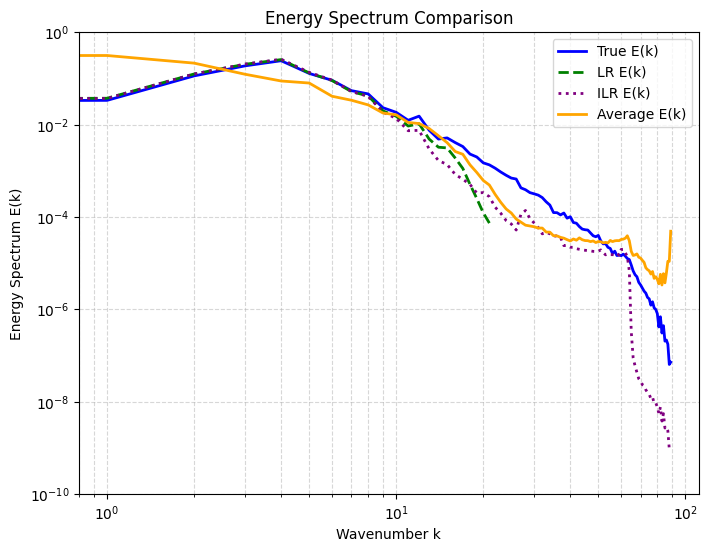

In [ ]:
def compute_energy_spectrum(u, v, w):
    nx, ny = u.shape
    u_hat = np.fft.fft2(u) / (nx * ny)
    v_hat = np.fft.fft2(v) / (nx * ny)
    w_hat = np.fft.fft2(w) / (nx * ny)
    u_hat_shifted = np.fft.fftshift(u_hat)
    v_hat_shifted = np.fft.fftshift(v_hat)
    w_hat_shifted = np.fft.fftshift(w_hat)

    dx = 2 * np.pi / nx
    dy = 2 * np.pi / ny
    k_x = np.fft.fftfreq(nx, d=dx) * 2 * np.pi
    k_y = np.fft.fftfreq(ny, d=dy) * 2 * np.pi
    k_x = np.fft.fftshift(k_x)
    k_y = np.fft.fftshift(k_y)

    k_x, k_y = np.meshgrid(k_x, k_y, indexing='ij')
    k = np.sqrt(k_x**2 + k_y**2)

    energy_spectrum = 0.5 * (np.abs(u_hat_shifted)**2 + np.abs(v_hat_shifted)**2 + np.abs(w_hat_shifted)**2)

    k_bins = np.arange(0, np.max(k), 1)
    E_k = np.zeros_like(k_bins[:-1])

    for i in range(len(k_bins) - 1):
        indices = (k >= k_bins[i]) & (k < k_bins[i + 1])
        E_k[i] = np.sum(energy_spectrum[indices])

    E_k = E_k / np.sum(E_k)

    return k_bins[:-1], E_k

# 여러 개의 테스트 데이터에 대해 에너지 스펙트럼을 평균화하는 코드
def average_energy_spectrum(data_list):
    # 각 데이터에 대해 에너지 스펙트럼을 계산하고 평균화
    # k_all, E_k_all 초기화
    k_all = None
    E_k_all = None
    for data in data_list:
        u, v, w = data
        k, E_k = compute_energy_spectrum(u, v, w)

        if k_all is None:  # 첫 번째 데이터의 k값을 저장
            k_all = k
            E_k_all = E_k
        else:
            # 각 에너지 스펙트럼을 합산
            E_k_all += E_k

    # 평균 계산
    E_k_all /= len(data_list)

    return k_all, E_k_all

# pred_test = 복원된 고해상도 데이터
pred_test = esrcnn_model.predict(lr_test)

data_list = []

# hr_test에서 각 데이터의 u, v, w 성분을 추출하여 data_list에 추가
for i in range(len(pred_test)):
    u = pred_test[i][:, :, 0]  # 첫 번째 성분 (u)
    v = pred_test[i][:, :, 1]  # 두 번째 성분 (v)
    w = np.zeros_like(u)  # w = 0으로 대체

    # 각 데이터 샘플을 튜플 형태로 묶어서 data_list에 추가
    data_list.append((u, v, w))

# 평균 에너지 스펙트럼 계산
k_avg, E_k_avg = average_energy_spectrum(data_list)

# 원본, 예측된, 저해상도, 고해상도 이미지에 대한 에너지 스펙트럼 계산
def safe_extract_uv_w(img):
    u = img[:, :, 0]
    v = img[:, :, 1]
    if img.shape[-1] >= 3:
        w = img[:, :, 2]
    else:
        w = np.zeros_like(u)  # w 채널이 없기에 영행렬로 대체
    return u, v, w

u_lr, v_lr, w_lr = safe_extract_uv_w(lr_img_show)
u_ilr, v_ilr, w_ilr = safe_extract_uv_w(bicubic_img)
u_pred, v_pred, w_pred = safe_extract_uv_w(predicted_img)
u_true, v_true, w_true = safe_extract_uv_w(hr_img_test)

k_lr, E_k_lr = compute_energy_spectrum(u_lr, v_lr, w_lr)
k_ilr, E_k_ilr = compute_energy_spectrum(u_ilr, v_ilr, w_ilr)
# k_pred, E_k_pred = compute_energy_spectrum(u_pred, v_pred, w_pred)
k_true, E_k_true = compute_energy_spectrum(u_true, v_true, w_true)

# 시각화
plt.figure(figsize=(8, 6))
plt.loglog(k_true, E_k_true, label="True E(k)", linewidth=2, color='b')
# plt.loglog(k_pred, E_k_pred, label="Predicted E(k)", linewidth=2, color='r')
plt.loglog(k_lr, E_k_lr, label="LR E(k)", linewidth=2, linestyle='dashed', color='g')
plt.loglog(k_ilr, E_k_ilr, label="ILR E(k)", linewidth=2, linestyle='dotted', color='purple')
plt.loglog(k_avg, E_k_avg, label="Average E(k)", linewidth=2, linestyle='-', color='orange')
plt.ylim(1e-10, 1.0)
plt.xlabel("Wavenumber k")
plt.ylabel("Energy Spectrum E(k)")
plt.title("Energy Spectrum Comparison")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()

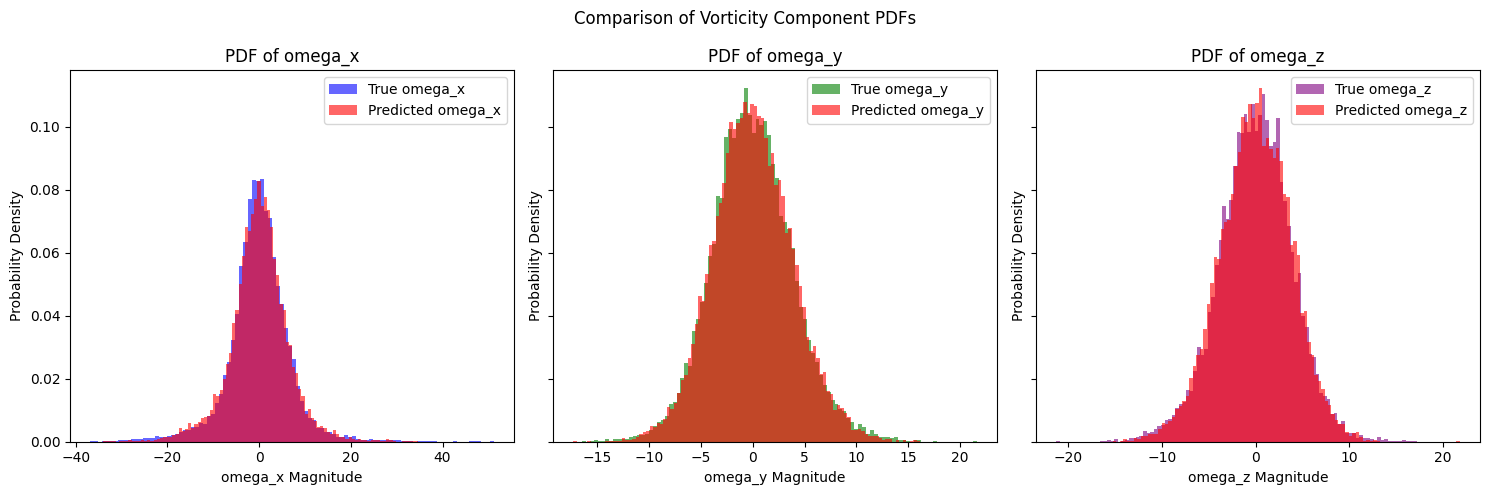

In [ ]:
# 격자 크기 (256, 1, 256)
Nx, Ny, Nz = 128, 1, 128

# 격자 간격 설정
dx = 1.0 / Nx  # dx = 1/128
dy = 1.0 / Ny  # dy = 1/1 (실제 의미 없음)
dz = 1.0 / Nz  # dz = 1/128

# 와도 계산 함수
def compute_vorticity(u, v, w, dx, dy, dz):
    """
    주어진 속도 성분 u, v, w에 대해 와도 벡터를 계산하는 함수
    """
    if u.ndim == 2:
        Nx, Nz = u.shape
        Ny = 1
        u = u.reshape(Nx, Ny, Nz)
        v = v.reshape(Nx, Ny, Nz)
        w = w.reshape(Nx, Ny, Nz)
    else:
        Nx, Ny, Nz = u.shape  # 이미 3D면 그대로 사용

    # 미분 계산
    dvdx = np.gradient(v, dx, axis=0)
    dudy = 0
    dwdx = np.gradient(w, dx, axis=0)
    dvdz = np.gradient(v, dz, axis=2)
    dwdy = 0
    dudz = np.gradient(u, dz, axis=2)

    # 와도 계산
    omega_x = dwdy - dvdz
    omega_y = dudz - dwdx
    omega_z = dvdx - dudy

    return omega_x, omega_y, omega_z

def safe_extract_uv_w(img):
    u = img[:, :, 0]
    v = img[:, :, 1]
    if img.shape[-1] >= 3:
        w = img[:, :, 2]
    else:
        w = np.zeros_like(u)
    return u, v, w

# 적용
u_pred, v_pred, w_pred = safe_extract_uv_w(predicted_img)
u_true, v_true, w_true = safe_extract_uv_w(hr_img_test)

# 실제 속도장과 예측 속도장의 와도 계산
omega_x_true, omega_y_true, omega_z_true = compute_vorticity(u_true, v_true, w_true, dx, dy, dz)
omega_x_pred, omega_y_pred, omega_z_pred = compute_vorticity(u_pred, v_pred, w_pred, dx, dy, dz)

# 1D 배열로 변환하여 히스토그램 작성
bins = 100
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

omega_components = ["omega_x", "omega_y", "omega_z"]
true_vorticities = [omega_x_true, omega_y_true, omega_z_true]
pred_vorticities = [omega_x_pred, omega_y_pred, omega_z_pred]
colors = ['blue', 'green', 'purple']

for i in range(3):
    true_data = true_vorticities[i].flatten()
    pred_data = pred_vorticities[i].flatten()

    axes[i].hist(true_data, bins=bins, density=True, alpha=0.6, label="True " + omega_components[i], color=colors[i])
    axes[i].hist(pred_data, bins=bins, density=True, alpha=0.6, label="Predicted " + omega_components[i], color='red')

    axes[i].set_xlabel(f"{omega_components[i]} Magnitude")
    axes[i].set_ylabel("Probability Density")
    axes[i].legend()
    axes[i].set_title(f"PDF of {omega_components[i]}")

plt.suptitle("Comparison of Vorticity Component PDFs")
plt.tight_layout()
plt.show()

3/3 [==============================] - 1s 218ms/step


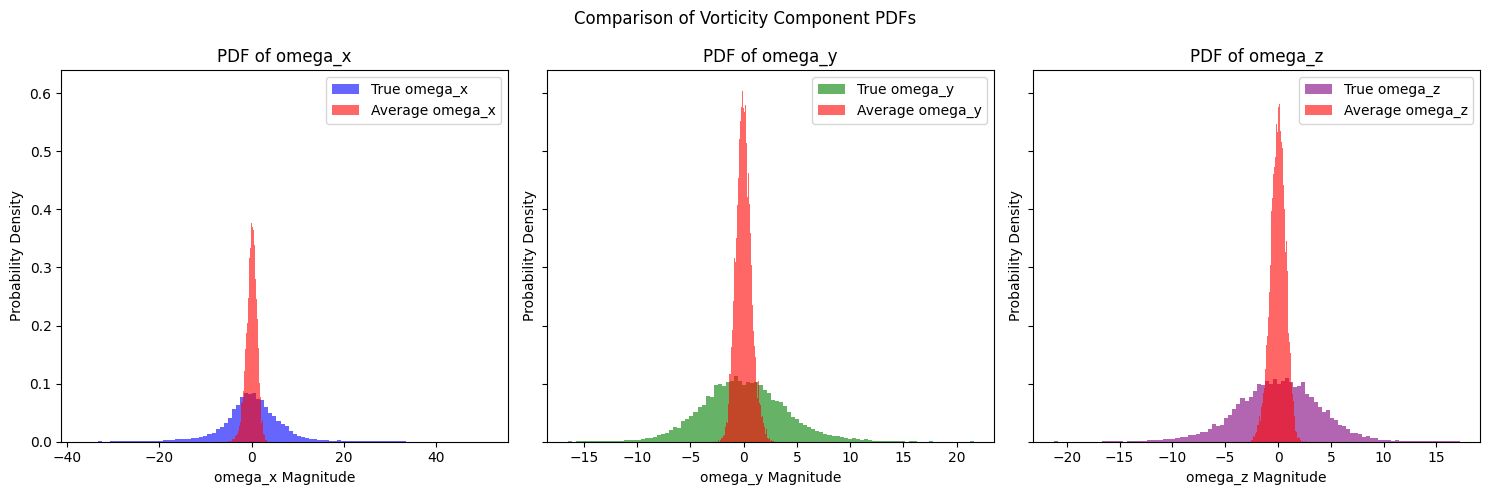

In [ ]:
# 격자 크기 (256, 1, 256)
Nx, Ny, Nz = 128, 1, 128

# 격자 간격 설정
dx = 1.0 / Nx  # dx = 1/128
dy = 1.0 / Ny  # dy = 1/1 (실제 의미 없음)
dz = 1.0 / Nz  # dz = 1/128

# 와도 계산 함수
def compute_vorticity(u, v, w, dx, dy, dz):
    """
    주어진 속도 성분 u, v, w에 대해 와도 벡터를 계산하는 함수
    """
    if u.ndim == 2:
        Nx, Nz = u.shape
        Ny = 1
        u = u.reshape(Nx, Ny, Nz)
        v = v.reshape(Nx, Ny, Nz)
        w = w.reshape(Nx, Ny, Nz)
    else:
        Nx, Ny, Nz = u.shape  # 이미 3D면 그대로 사용

    # 미분 계산
    dvdx = np.gradient(v, dx, axis=0)
    dudy = 0
    dwdx = np.gradient(w, dx, axis=0)
    dvdz = np.gradient(v, dz, axis=2)
    dwdy = 0
    dudz = np.gradient(u, dz, axis=2)

    # 와도 계산
    omega_x = dwdy - dvdz
    omega_y = dudz - dwdx
    omega_z = dvdx - dudy

    return omega_x, omega_y, omega_z

# 전체 데이터에 대한 와도 계산 함수
def compute_average_vorticity(u_list, v_list, w_list, dx, dy, dz):
    omega_x_total = []
    omega_y_total = []
    omega_z_total = []

    for u, v, w in zip(u_list, v_list, w_list):
        omega_x, omega_y, omega_z = compute_vorticity(u, v, w, dx, dy, dz)
        omega_x_total.append(omega_x)  # 와도 x 성분을 추가
        omega_y_total.append(omega_y)  # 와도 y 성분을 추가
        omega_z_total.append(omega_z)  # 와도 z 성분을 추가

    # 각 데이터 샘플별로 평균 와도 계산
    omega_x_avg = np.mean(omega_x_total, axis=0)  # 각 샘플에 대해 평균 계산
    omega_y_avg = np.mean(omega_y_total, axis=0)  # 각 샘플에 대해 평균 계산
    omega_z_avg = np.mean(omega_z_total, axis=0)  # 각 샘플에 대해 평균 계산

    return omega_x_avg, omega_y_avg, omega_z_avg

# pred_test = 복원된 고해상도 데이터
pred_test = esrcnn_model.predict(lr_test)

u_list, v_list, w_list = [], [], []

# 각 예측 결과에서 u, v, w 추출
for i in range(len(pred_test)):
    u, v, w = safe_extract_uv_w(pred_test[i])
    u_list.append(u)
    v_list.append(v)
    w_list.append(w)

# 원본 속도장도 마찬가지로 처리
u_true, v_true, w_true = safe_extract_uv_w(hr_img_test)

# 와도 계산
omega_x_true, omega_y_true, omega_z_true = compute_vorticity(u_true, v_true, w_true, dx, dy, dz)
omega_x_avg, omega_y_avg, omega_z_avg = compute_average_vorticity(u_list, v_list, w_list, dx, dy, dz)


# 히스토그램 작성
bins = 100
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

omega_components = ["omega_x", "omega_y", "omega_z"]
true_vorticities = [omega_x_true, omega_y_true, omega_z_true]
avg_vorticities = [omega_x_avg, omega_y_avg, omega_z_avg]
colors = ['blue', 'green', 'purple']

for i in range(3):
    # 원본 속도장의 vorticity pdf
    true_data = true_vorticities[i]
    # 평균 vorticity pdf
    avg_data = avg_vorticities[i]

    axes[i].hist(true_data.flatten(), bins=bins, density=True, alpha=0.6, label="True " + omega_components[i], color=colors[i])
    axes[i].hist(avg_data.flatten(), bins=bins, density=True, alpha=0.6, label="Average " + omega_components[i], color='red')

    axes[i].set_xlabel(f"{omega_components[i]} Magnitude")
    axes[i].set_ylabel("Probability Density")
    axes[i].legend()
    axes[i].set_title(f"PDF of {omega_components[i]}")

plt.suptitle("Comparison of Vorticity Component PDFs")
plt.tight_layout()
plt.show()

In [ ]:
print(pred_test.shape)
print(u.shape)

(200, 128, 128, 3)
(128, 128)


In [ ]:
from scipy.stats import pearsonr
from skimage.metrics import structural_similarity as ssim

# 피어슨 상관계수
true_velocity = hr_img_test[:, :, :].flatten()
pred_velocity = predicted_img[:, :, :].flatten()
corr, _ = pearsonr(true_velocity, pred_velocity)
print(f"Pearson Correlation Coefficient: {corr:.4f}")

# SSIM
win_size = 3
ssim_value = ssim(hr_img_test, predicted_img,
                  channel_axis=-1,
                  win_size=win_size,
                  data_range=predicted_img.max() - predicted_img.min())
print(f"SSIM: {ssim_value:.4f}")

Pearson Correlation Coefficient: 0.9888
SSIM: 0.8532


In [ ]:
# pred_test = 복원된 고해상도 데이터
pred_test = esrcnn_model.predict(lr_test)

data_list = []

# 안전하게 u, v, w 성분 추출
for i in range(len(pred_test)):
    u, v, w = safe_extract_uv_w(pred_test[i])
    data_list.append((u, v, w))

# 연속 방정식의 오차 계산 함수
def compute_continuity_error(u, v, w, dx, dy, dz):
    du_dx = np.gradient(u, dx, axis=0)
    dv_dy = 0  # y 방향은 2D 평면이므로 무시
    dw_dz = np.gradient(w, dz, axis=1)
    continuity_error = du_dx + dv_dy + dw_dz
    error_magnitude = np.abs(continuity_error)
    error_avg = np.mean(error_magnitude)
    return error_avg

# 평균 오차 계산 함수
def compute_average_continuity_error(data_list, dx, dy, dz):
    error_list = []
    for u, v, w in data_list:
        error_avg = compute_continuity_error(u, v, w, dx, dy, dz)
        error_list.append(error_avg)
    total_error_avg = np.mean(error_list)
    return total_error_avg, error_list

# 격자 간격
dx = 1.0 / 128
dy = 1.0  # 의미 없음
dz = 1.0 / 128

# 계산 실행
total_error_avg, error_list = compute_average_continuity_error(data_list, dx, dy, dz)

print("Total Average Continuity Error:", total_error_avg)


3/3 [==============================] - 1s 215ms/step
Total Average Continuity Error: 3.1735873


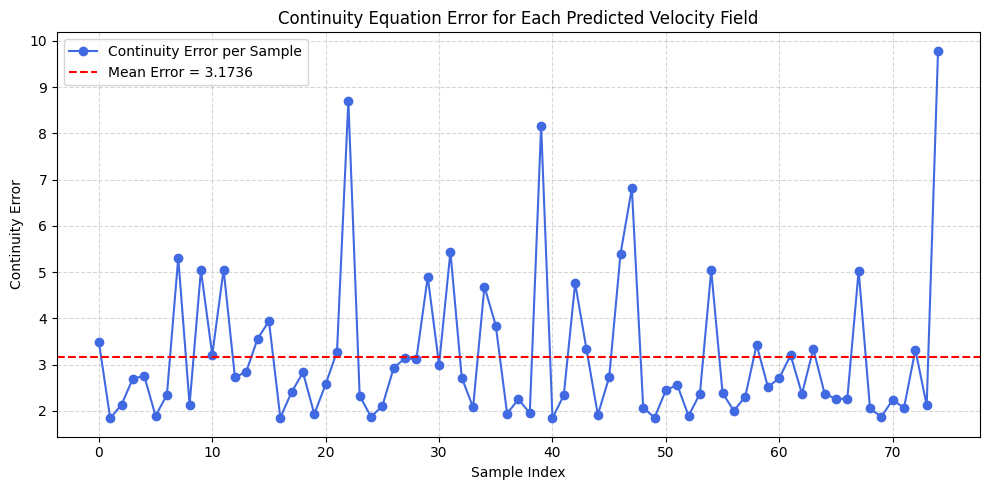

In [ ]:
# 데이터 인덱스
sample_indices = np.arange(len(error_list))

# 시각화
plt.figure(figsize=(10, 5))
plt.plot(sample_indices, error_list, marker='o', linestyle='-', color='royalblue', label='Continuity Error per Sample')
plt.axhline(y=total_error_avg, color='red', linestyle='--', label=f"Mean Error = {total_error_avg:.4f}")

plt.xlabel("Sample Index")
plt.ylabel("Continuity Error")
plt.title("Continuity Equation Error for Each Predicted Velocity Field")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

   lambda  Continuity Error Avg
0     0.1              6.315665
1     0.5              6.290532
2     1.0              6.414516
3     2.5              6.330083
4     5.0              6.326173
5    10.0              6.485546
6    25.0              6.239550


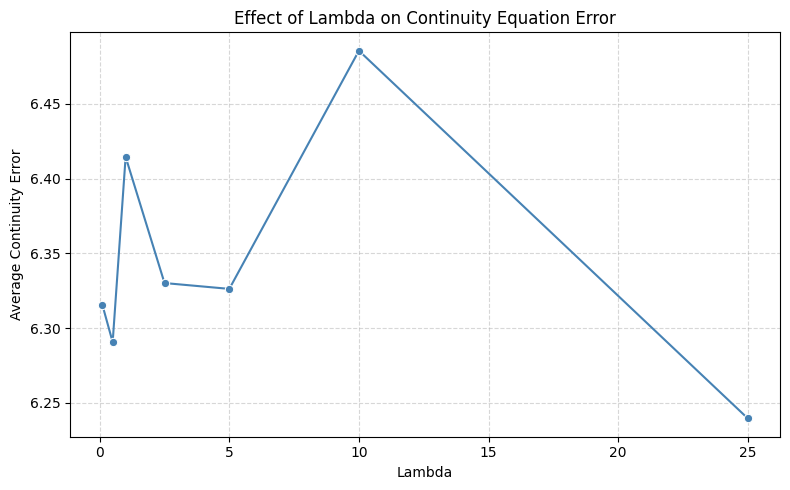

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 데이터 입력
data = {
    "lambda": [0.1, 0.5, 1.0, 2.5, 5.0, 10.0, 25.0],
    "Continuity Error Avg": [6.3156652, 6.290532, 6.414516, 6.330083, 6.3261733, 6.4855456, 6.2395496]
}

# 데이터프레임 생성
df = pd.DataFrame(data)

# 표 출력
print(df)

# 그래프 시각화
plt.figure(figsize=(8, 5))
sns.lineplot(x="lambda", y="Continuity Error Avg", data=df, marker='o', color='steelblue')
plt.xlabel("Lambda")
plt.ylabel("Average Continuity Error")
plt.title("Effect of Lambda on Continuity Equation Error")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# lambda 값에 따른 평균 error

lambda = 0.1 => error_avg = 6.3156652
lambda = 0.5 => error_avg = 6.290532
lambda = 1.0 => error_avg = 6.414516
lambda = 2.5 => error_avg = 6.330083
lambda = 5.0 => error_avg = 6.3261733
lambda = 10.0 => error_avg = 6.4855456
lambda = 25.0 => error_avg = 6.2395496

In [ ]:
## test 데이터를 average pooling하여 저해상화 (4, 4) 또는 (8, 8) pooling ##
# 저해상도 데이터 생성
lrt_test= generator_pooling(test_data)

# 공간 초해상화, xt_pred 생성
xt_pred = esrcnn_model.predict(lrt_test)

# 정규화
mean_val = np.mean(xt_pred)
std_val = np.std(xt_pred)
train_data_norm = (xt_pred - mean_val) / std_val

# Inbetweening test input 생성
xt_test, _ = create_inbetweening_dataset(xt_pred)
yt_test = np.zeros((xt_test[0].shape[0], 3, 128, 128, 2))

5/5 [==============================] - 2s 318ms/step


In [ ]:
EPOCHS = 500
batch_size = 16
history = Inbetweening_model.fit(
    xt_train, yt_train,
    batch_size=batch_size,
    epochs=EPOCHS,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/500
19/19 [==============================] - 21s 1s/step - loss: 77766.0938
Epoch 2/500
19/19 [==============================] - 19s 1s/step - loss: 839.9291
Epoch 3/500
19/19 [==============================] - 19s 1s/step - loss: 8.8182
Epoch 4/500
19/19 [==============================] - 19s 1s/step - loss: 2.7668
Epoch 5/500
19/19 [==============================] - 19s 1s/step - loss: 1.8443
Epoch 6/500
19/19 [==============================] - 19s 1s/step - loss: 1.4847
Epoch 7/500
19/19 [==============================] - 19s 1s/step - loss: 1.2981
Epoch 8/500
19/19 [==============================] - 19s 1s/step - loss: 1.1999
Epoch 9/500
19/19 [==============================] - 19s 1s/step - loss: 1.1475
Epoch 10/500
19/19 [==============================] - 19s 1s/step - loss: 1.1176
Epoch 11/500
19/19 [==============================] - 19s 1s/step - loss: 1.0995
Epoch 12/500
19/19 [==============================] - 19s 1s/step - loss: 1.0859
Epoch 13/500
19/19 [===========

In [ ]:
# 저장할 경로 설정
save_path_Inbetweening = "/content/drive/MyDrive/weight/weights_Inbetweening_128_1.0.h5"

# weight 폴더가 없으면 생성
os.makedirs(os.path.dirname(save_path), exist_ok=True)

In [ ]:
# 모델 가중치 저장
Inbetweening_model.save_weights(save_path_Inbetweening)
print(f"🔹 가중치 저장 완료! 저장 경로: {save_path_Inbetweening}")

🔹 가중치 저장 완료! 저장 경로: /content/drive/MyDrive/weight/weights_Inbetweening_128_1.0.h5


In [ ]:
# 저장된 가중치 불러오기
Inbetweening_model.load_weights(save_path_Inbetweening)
print("🔹 가중치 불러오기 완료!")

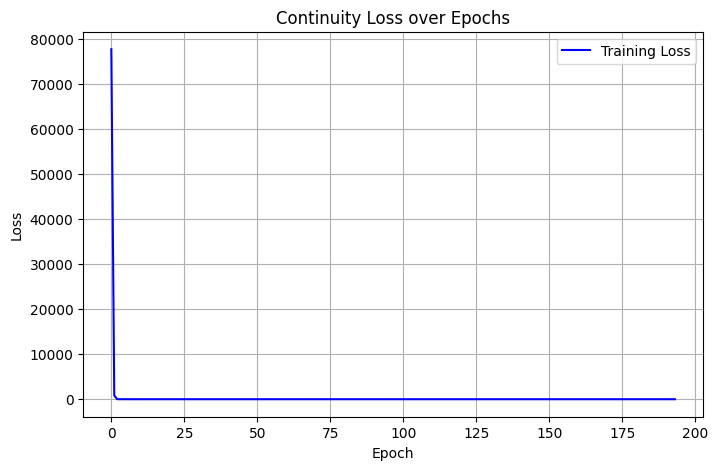

In [ ]:
# loss graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Continuity Loss over Epochs')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# 하나의 샘플을 테스트
sample_idx = np.random.randint(0, 75)
start_frame = xt_test[0][sample_idx]   # shape: (128, 128, 2)
end_frame   = xt_test[1][sample_idx]

# 모델 예측 (출력 shape: (1, 3, 128, 128, 2))
predicted_middle = Inbetweening_model.predict([start_frame[np.newaxis, ...], end_frame[np.newaxis, ...]])[0]

# 정규화 복원, 다른 평균, 표준편차가 쓰이지 않도록 주의
start_frame = start_frame * std_val + mean_val
end_frame   = end_frame * std_val + mean_val
predicted_middle = predicted_middle * std_val + mean_val

1/1 [==============================] - 0s 32ms/step


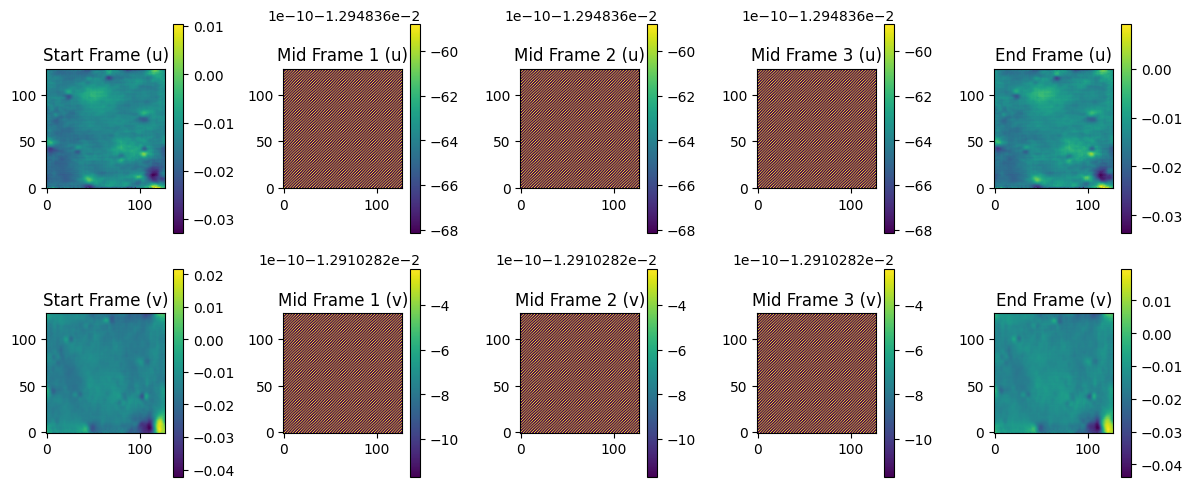

In [ ]:
# 시각화: 5개 프레임 × 2채널 (imshow)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# 프레임 데이터와 타이틀 정리
frames = [start_frame] + [predicted_middle[i] for i in range(3)] + [end_frame]
titles = ["Start Frame", "Mid Frame 1", "Mid Frame 2", "Mid Frame 3", "End Frame"]

for i in range(5):
    u = frames[i][:, :, 0]
    v = frames[i][:, :, 1]

    im_u = axes[0, i].imshow(u, origin='lower')
    fig.colorbar(im_u, ax=axes[0, i])
    axes[0, i].set_title(f"{titles[i]} (u)")

    im_v = axes[1, i].imshow(v, origin='lower')
    fig.colorbar(im_v, ax=axes[1, i])
    axes[1, i].set_title(f"{titles[i]} (v)")

plt.tight_layout()
plt.show()

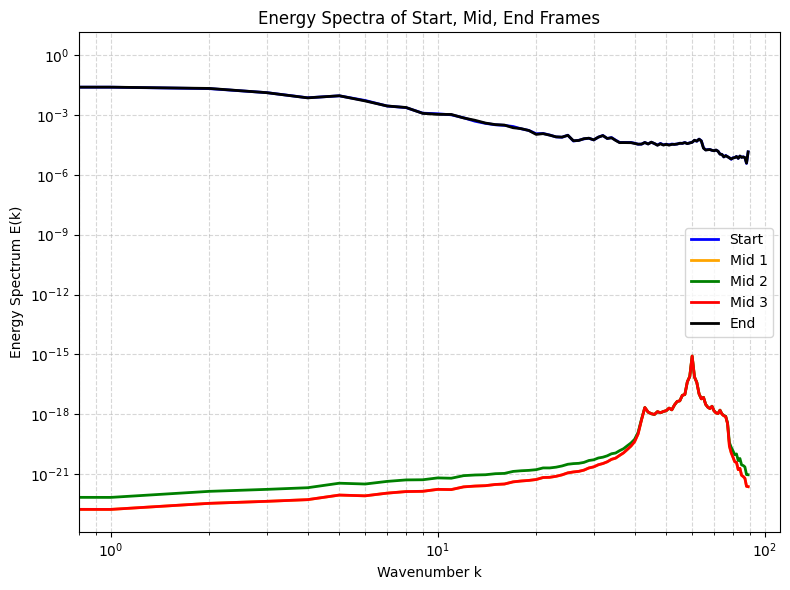

In [ ]:
# 운동 에너지 스펙트럼 분석
def compute_energy_spectrum(u, v, w=None):
    nx, ny = u.shape
    u_hat = np.fft.fft2(u) / (nx * ny)
    v_hat = np.fft.fft2(v) / (nx * ny)
    if w is None:
        w_hat = np.zeros_like(u_hat)
    else:
        w_hat = np.fft.fft2(w) / (nx * ny)

    u_hat_shifted = np.fft.fftshift(u_hat)
    v_hat_shifted = np.fft.fftshift(v_hat)
    w_hat_shifted = np.fft.fftshift(w_hat)

    dx = 2 * np.pi / nx
    dy = 2 * np.pi / ny

    k_x = np.fft.fftfreq(nx, d=dx) * 2 * np.pi
    k_y = np.fft.fftfreq(ny, d=dy) * 2 * np.pi
    k_x = np.fft.fftshift(k_x)
    k_y = np.fft.fftshift(k_y)

    k_x, k_y = np.meshgrid(k_x, k_y, indexing='ij')
    k = np.sqrt(k_x**2 + k_y**2)

    energy_spectrum = 0.5 * (np.abs(u_hat_shifted)**2 + np.abs(v_hat_shifted)**2 + np.abs(w_hat_shifted)**2)

    k_bins = np.arange(0, np.max(k), 1)
    E_k = np.zeros_like(k_bins[:-1])

    for i in range(len(k_bins) - 1):
        indices = (k >= k_bins[i]) & (k < k_bins[i + 1])
        E_k[i] = np.sum(energy_spectrum[indices])

    E_k = E_k / np.sum(E_k)
    return k_bins[:-1], E_k

def plot_energy_spectra_timeline(start_frame, predicted_middle, end_frame):
    """
    시작 프레임, 중간 3프레임, 마지막 프레임의 에너지 스펙트럼을 한 그래프에 그리는 함수.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    # 프레임들 정리
    frames = [start_frame] + [predicted_middle[i] for i in range(3)] + [end_frame]
    labels = ['Start', 'Mid 1', 'Mid 2', 'Mid 3', 'End']
    colors = ['blue', 'orange', 'green', 'red', 'black']

    for frame, label, color in zip(frames, labels, colors):
        u = frame[:, :, 0]
        v = frame[:, :, 1]
        k, E_k = compute_energy_spectrum(u, v)
        ax.loglog(k, E_k, label=label, linewidth=2, color=color)

    ax.set_xlabel("Wavenumber k")
    ax.set_ylabel("Energy Spectrum E(k)")
    ax.set_title("Energy Spectra of Start, Mid, End Frames")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_energy_spectra_timeline(start_frame, predicted_middle, end_frame)

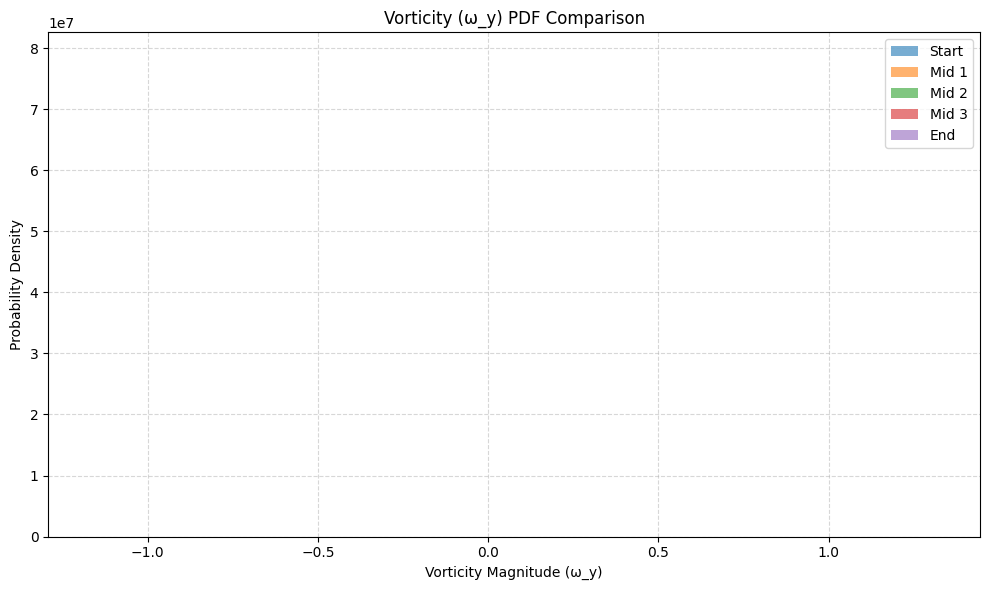

In [ ]:
# vorticity pdf 분석
def compute_vorticity(u, v, dx=1/128, dz=1/128):
    """
    2D xz 평면 기준으로 ω_y 계산
    """
    dvdx = np.gradient(v, dx, axis=0)  # ∂v/∂x
    dudz = np.gradient(u, dz, axis=1)  # ∂u/∂z
    omega_y = dudz - dvdx
    return omega_y

def plot_vorticity_pdf(frames, labels, dx=1/128, dz=1/128, bins=100):
    """
    주어진 프레임 리스트 (u, v 성분 포함)에 대해 ω_y PDF 비교 시각화
    """
    plt.figure(figsize=(10, 6))

    for i, frame in enumerate(frames):
        u = frame[:, :, 0]
        v = frame[:, :, 1]
        omega_y = compute_vorticity(u, v, dx, dz)
        plt.hist(omega_y.flatten(), bins=bins, density=True, alpha=0.6, label=labels[i])

    plt.xlabel("Vorticity Magnitude (ω_y)")
    plt.ylabel("Probability Density")
    plt.title("Vorticity (ω_y) PDF Comparison")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# frame 목록: 시작, 중간 3개, 끝 프레임
all_frames = [start_frame] + [predicted_middle[i] for i in range(3)] + [end_frame]
frame_labels = ["Start", "Mid 1", "Mid 2", "Mid 3", "End"]

plot_vorticity_pdf(all_frames, frame_labels)

In [ ]:
# continuity error 계산
def compute_continuity_error(u, v, w, dx, dy, dz):
    """
    ∇·u = ∂u/∂x + ∂v/∂y + ∂w/∂z
    2D 평면에서 ∂v/∂y는 무시됨 (dy=1 기준)
    """
    du_dx = np.gradient(u, dx, axis=0)
    dv_dy = 0  # y 방향은 두께 1이므로 미분 불가
    dw_dz = np.gradient(w, dz, axis=1)

    continuity_error = du_dx + dv_dy + dw_dz
    error_magnitude = np.abs(continuity_error)
    error_avg = np.mean(error_magnitude)

    return error_avg

def compute_all_continuity_errors(data_list, dx, dy, dz):
    """
    각 프레임에 대한 continuity error 평균을 계산하여 리스트 반환
    """
    error_list = []

    for i, (u, v, w) in enumerate(data_list):
        error = compute_continuity_error(u, v, w, dx, dy, dz)
        error_list.append(error)

    return error_list

# 데이터: [(u, v, w), (u, v, w), ...]
# dx, dy, dz는 격자 간격
dx, dy, dz = 1.0 / 128, 1.0 / 128, 1.0

data_list = []

# 1. 시작 프레임
u_start = start_frame[:, :, 0]
v_start = start_frame[:, :, 1]
w_start = np.zeros_like(u_start)
data_list.append((u_start, v_start, w_start))

# 2. 중간 프레임들 (예측 결과 또는 ground truth 중 일부일 수 있음)
for i in range(3):
    u_mid = predicted_middle[i, :, :, 0]
    v_mid = predicted_middle[i, :, :, 1]
    w_mid = np.zeros_like(u_mid)
    data_list.append((u_mid, v_mid, w_mid))

# 3. 마지막 프레임
u_end = end_frame[:, :, 0]
v_end = end_frame[:, :, 1]
w_end = np.zeros_like(u_end)
data_list.append((u_end, v_end, w_end))

# continuity error 계산
error_list = compute_all_continuity_errors(data_list, dx, dy, dz)

# 출력
for i, err in enumerate(error_list):
    print(f"Frame {i}: Continuity Error = {err:.6f}")

# 전체 평균 오차
total_error_avg = np.mean(error_list)
print(f"\n➡️ Total Average Continuity Error: {total_error_avg:.6f}")


Frame 0: Continuity Error = 0.087056
Frame 1: Continuity Error = 0.000000
Frame 2: Continuity Error = 0.000000
Frame 3: Continuity Error = 0.000000
Frame 4: Continuity Error = 0.086823

➡️ Total Average Continuity Error: 0.034776
